This makes KS tests. There are 2d KS test earlier on in the notebook and then 1d KS-test latter on. Unfortunatly there is also a bit of stuff that could be removed although it has been moved into a different note book (ks-comparison)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde, ks_2samp, kstest
from hyppo.ksample import Energy
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime
from matplotlib.ticker import AutoLocator

# Setup and helper functions moved to external module
from equations_file import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [2]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [3]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.8)
                        # & (galah_Gaia_raw['fe_h'] < -0.8)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [4]:
# NGC5139_Galah = galah_Gaia[(galah_Gaia['ra'] > 201.2)
#                              & (galah_Gaia['ra'] < 202.2) 
#                              & (galah_Gaia['dec'] > -47.8)
#                              & (galah_Gaia['dec'] < -47.2)
#                              & (galah_Gaia['pmra'] < 1)
#                              & (galah_Gaia['pmra'] > -6)
#                              & (galah_Gaia['pmdec'] < -4)
#                              & (galah_Gaia['pmdec'] > -10)
#                              & (galah_Gaia['jphi'] < 0)
#                              ]

# NGC3201_Galah = galah_Gaia[(galah_Gaia['pmra'] > 6.5)
#                             & (galah_Gaia['pmra'] < 10)
#                             & (galah_Gaia['pmdec'] > -3.5)
#                             & (galah_Gaia['pmdec'] < -1)
#                             # & (galah_Gaia['fe_h'] < 0.0)
#                             & (galah_Gaia['ra'] > 152)
#                             & (galah_Gaia['ra'] < 156)
#                             & (galah_Gaia['dec'] > -49)
#                             & (galah_Gaia['dec'] < -44)
#                             & (galah_Gaia['jphi'] < 0)
#                             ]

NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            # & (galah_Gaia['fe_h'] < -1.0)
                            ]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia['fe_h'] < -1.0)
                            # & (galah_Gaia['fe_h'] > -1.9)
                            # & (galah_Gaia_raw['ti_fe'] > 0.25)
                             ]


/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_69021/2345862974.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [5]:
Halo_Pradosh_galah_Gaia = galah_Gaia[(galah_Gaia['fe_h'] < -0.8)
                                            & (galah_Gaia['ti_fe'] > 0.25)
                                            # & (galah_Gaia['flag_ti_fe'] == 0)
                                            & (galah_Gaia['Lz'] > -1500)
                                            & (galah_Gaia['Lz'] < 1500)
                                            & (galah_Gaia['ecc_gaia'] > 0.5)
                                            & (galah_Gaia['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia[(galah_Gaia['fe_h'] < -0.8)
                                                 & (galah_Gaia['ti_fe'] > 0.25)
                                                #  & (galah_Gaia['flag_ti_fe'] == 0)
                                                 & (galah_Gaia['Lz'] > 0)
                                                 & (galah_Gaia['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]
print(len(Halo_Pradosh_galah_Gaia))
print(len(thickdisk_galah_Gaia))

1840
2659


In [6]:
print(len(galah_Gaia_Sequoia))
print(len(galah_Gaia_GSE))
print(len(galah_Gaia_Halo))

126
844
3184


In [7]:
random_5000_1 = galah_Gaia.sample(n=2290)

random_5000_1_mask = (~galah_Gaia['sobject_id'].isin(random_5000_1['sobject_id']))

random_5000_2 = galah_Gaia[random_5000_1_mask].sample(n=575)

In [89]:
element_list_full_galah = ["h", "fe", "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti" "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_partial_small_galah_1 = [ 'fe', 'ca', 'ti', 'na', 'mn', 'cu','mg']
element_list_partial_small_galah_2 = [ 'fe', 'ca', 'na', 'mn', 'cu','mg', 'nd']
element_list_partial_small_galah_3 = [ 'cu', 'ca', 'mn', 'ni','v','na', 'nd']
element_list_partial_small_galah_4 = [ 'cu', 'ca', 'mn', 'ti','v','na', 'nd']
element_list_partial_small_galah_5 = [ 'cu', 'ca', 'mn', 'ti','ba','na', 'nd']
element_list_partial_small_galah_6 = [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba','na', 'nd']
element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_8 = [ 'ca', 'mn', 'y', 'v', 'na', 'nd', 'cr', 'sc']
element_list_partial_small_galah_9 = [ 'cu', 'ca', 'mn', 'ti', 'sc', 'v', 'na', 'nd']
element_list_partial_small_galah_15_1 = ['na', 'ca', 'cr', 'mn', 'cu', 'y', 'nd'] # this is for RFC to compare the Halo and GSE with the elm selection form 
element_list_partial_small_galah_16 =  ["na", "mg", "ca", "ti", "cr" ,"mn", "ni", 'cu', 'y', "ba", "nd"]


elements_in_Pradosh_Galah_1 = ['ca', 'ti', 'ni','zr', 'ce', 'nd']
elements_in_Pradosh_Galah_2 = ['ca', 'ti', 'ni', 'nd']
element_list_full_galah_almost = ["n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "cr" ,"mn", "co", "ni", "cu", "zn", 'rb', 'sr', "y", "zr", 'mo', 'ru', "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.


element_list = element_list_partial_small_galah_16
# element_list = element_list_partial_small_galah_15_1

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(Halo_Pradosh_galah_Gaia, element_list)
Halo_Pradosh_galah_Gaia_new_ratios = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

random_5000_1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(random_5000_1, element_list)
random_5000_1_new_ratios = random_5000_1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

random_5000_2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(random_5000_2, element_list)
random_5000_2_new_ratios = random_5000_2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

'----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'

# element_list_full_galah_almost = ["n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "y", "zr", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_full_galah_almost = ["n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", 'rb', 'sr', "y", "zr", 'mo', 'ru', "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.


element_list_nessessary_flags = element_list_full_galah_almost

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia, element_list_nessessary_flags)
galah_Gaia_new_ratios_nessessary_flags_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]
galah_Gaia_new_ratios_nessessary_flags = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]


galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Sequoia, element_list_nessessary_flags)
galah_Gaia_Sequoia_new_ratios_nessessary_flags = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]
 
galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_GSE, element_list_nessessary_flags)
galah_Gaia_GSE_new_ratios_nessessary_flags = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Halo, element_list_nessessary_flags)
galah_Gaia_Halo_new_ratios_nessessary_flags = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(Halo_Pradosh_galah_Gaia, element_list_nessessary_flags)
Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]



/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:717: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_error_label] = np.sqrt((data_set_flagged[err_col_numerator])**2 + (data_set_flagged[err_col_denominator])**2)

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:716: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flagged[col_name_for_denominat

In [77]:
# Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
#                                             & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
#                                             & (galah_Gaia_new_ratios['Lz'] > -1500)
#                                             & (galah_Gaia_new_ratios['Lz'] < 1500)
#                                             & (galah_Gaia_new_ratios['ecc_gaia'] > 0.5)
#                                             & (galah_Gaia_new_ratios['ecc_gaia'] < 0.8)
#                                             # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
#                                             & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
#                                             & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
#                                             & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
#                                             & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
#                                             ]

# thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
#                                                  & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
#                                                  & (galah_Gaia_new_ratios['Lz'] > 0)
#                                                  & (galah_Gaia_new_ratios['ecc_gaia'] < 0.5)
#                                                 #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
#                                                 & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
#                                                 & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
#                                                 & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
#                                                 & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
#                                             ]
# print(len(Halo_Pradosh_galah_Gaia))
# print(len(thickdisk_galah_Gaia))

In [78]:
print(len(galah_Gaia_Sequoia_new_ratios))
print(len(galah_Gaia_Sequoia_new_ratios_nessessary_flags))

print(len(galah_Gaia_GSE_new_ratios))
print(len(galah_Gaia_GSE_new_ratios_nessessary_flags))

print(len(galah_Gaia_Halo_new_ratios))
print(len(galah_Gaia_Halo_new_ratios_nessessary_flags))

print(len(Halo_Pradosh_galah_Gaia_new_ratios))
print(len(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags))

67
126
561
844
2131
3184
1254
1840


In [79]:
print(f"THE NUMBER OF ELEMENTS IS {len(element_list)}")
print(f"THE NUMBER OF RATIOS IS {len(galah_gaia_new_element_ratio_list)}")
print("")
print(f"THE NUMBER OF ELEMENTS IS {len(element_list_nessessary_flags)}")
print(f"THE NUMBER OF RATIOS IS {len(galah_Gaia_new_ratios_nessessary_flags_ratio_list)}")

THE NUMBER OF ELEMENTS IS 12
THE NUMBER OF RATIOS IS 66

THE NUMBER OF ELEMENTS IS 29
THE NUMBER OF RATIOS IS 406


In [97]:
# one_by_one_element_list = element_list_nessessary_flags
# ratio_list = galah_Gaia_new_ratios_nessessary_flags_ratio_list

ratio_list = galah_gaia_new_element_ratio_list


# ratio_list = ['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni', 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na']
# ratio_list = ['v_ca', 'nd_y', 'cr_mn', 'na_mn']
# ratio_list = ['ca_v', 'v_fe', 'fe_h', 'na_sc']


object_list = {
                'GSE': (galah_Gaia_GSE_new_ratios,),  #df
                # 'Sequoia': (galah_Gaia_Sequoia_new_ratios,),
                # 'Halo': (galah_Gaia_Halo_new_ratios,),
                'Halo_Pradosh': (Halo_Pradosh_galah_Gaia_new_ratios,),
                # 'ran_1': (random_5000_1_new_ratios,),
                # 'ran_2': (random_5000_2_new_ratios,),
}

# object_list = {
#                 # 'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags,),  #df
#                 'Sequoia': (galah_Gaia_Sequoia_new_ratios_nessessary_flags,),
#                 # 'Halo': (galah_Gaia_Halo_new_ratios,),
#                 'Halo_Pradosh': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags,),
#                 # 'ran_1': (random_5000_1_new_ratios,),
#                 # 'ran_2': (random_5000_2_new_ratios,),
# }

# two_d_test_test_Halo_vs_Sequoia = two_d_ks_test(ratio_list, object_list, FE_H = True)

# two_d_test_test_GSE_vs_Sequoia = two_d_ks_test(ratio_list, object_list)

two_d_test_test_Halo_vs_GSE = two_d_ks_test(ratio_list, object_list)

# two_d_test_test_random_5000 = two_d_ks_test(ratio_list, object_list)


mg_na and ca_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'ca'}
Skipping mg_na and ca_na: shared segments = ['na']

mg_na and ti_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'ti'}
Skipping mg_na and ti_na: shared segments = ['na']

mg_na and cr_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'cr'}
Skipping mg_na and cr_na: shared segments = ['na']

mg_na and mn_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'mn'}
Skipping mg_na and mn_na: shared segments = ['na']

mg_na and ni_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'ni'}
Skipping mg_na and ni_na: shared segments = ['na']

mg_na and cu_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'cu'}
Skipping mg_na and cu_na: shared segments = ['na']

mg_na and y_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'y'}
Skipping mg_na and y_na: shared segments = ['na']

mg_na and ba_na
ratio1_tokens: {'na', 'mg'}
ratio2_tokens: {'na', 'ba'}
Skipping mg_na and ba_na: shared segments = ['na']

mg_na and 

In [13]:
two_d_test_test_Halo_vs_Sequoia.to_csv('Pradosh_Halo_Galah_phase1_2_Hermes_Halo_vs_Sequoia_2d_Energy_test_nessessary_flags_feH_lessthen_min0.8.csv', index=False)
# two_d_test_test_GSE_vs_Sequoia.to_csv('no_fe_yes_mg_Galah_phase1_2_Hermes_GSE_vs_Sequoia_2d_ks_test.csv', index=False)
# two_d_test_test_Halo_vs_GSE.to_csv('Pradosh_Halo_Galah_phase1_2_Hermes_Halo_vs_GSE_2d_ks_test.csv', index=False)

In [100]:
# two_d_test_test_Halo_vs_Sequoia.sort_values(by = 'statistic', ascending = False)[0:40]
two_d_test_test_Halo_vs_Sequoia[0:50]

# two_d_test_test_Halo_vs_Sequoia_check = two_d_test_test_Halo_vs_Sequoia[(two_d_test_test_Halo_vs_Sequoia['ratio 1'].isin(['v_ca', 'nd_y', 'na_mn', 'cr_na']))
#                                                                         & (two_d_test_test_Halo_vs_Sequoia['ratio 2'].isin(['v_ca', 'nd_y', 'na_mn', 'cr_na']))
#                                                                         ]

# two_d_test_test_Halo_vs_Sequoia_check

,ratio 1,ratio 2,p_value,statistic,num_samples_1,num_samples_2
191,ni_na,cu_ca,1.580794e-08,0.051999,67,1254
83,ti_na,cu_ca,1.769826e-08,0.056993,67,1254
47,ca_na,cu_ti,1.789666e-08,0.058311,67,1254
53,ca_na,cu_cr,1.802271e-08,0.058564,67,1254
119,cr_na,cu_ca,1.857837e-08,0.057392,67,1254
40,ca_na,cu_mg,2.036751e-08,0.058934,67,1254
62,ca_na,cu_ni,2.401471e-08,0.053425,67,1254
58,ca_na,cu_mn,2.759953e-08,0.055073,67,1254
4,mg_na,cu_ca,2.816582e-08,0.056659,67,1254
155,mn_na,cu_ca,3.823546e-08,0.053206,67,1254


(0.0, 100.0)

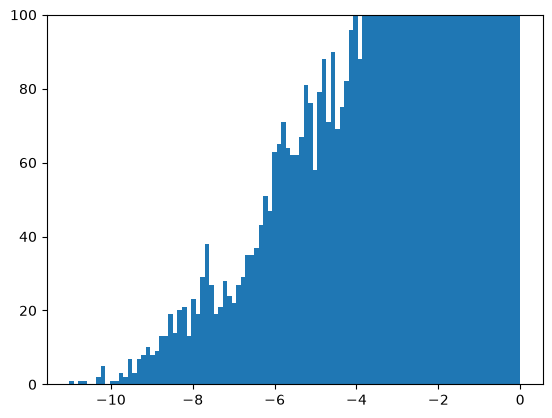

In [28]:
plt.hist(np.log10(two_d_test_test_Halo_vs_Sequoia['p_value']), bins=100)
plt.xlim(None, None)
plt.ylim(None, 100)

Text(0, 0.5, 'num stars')

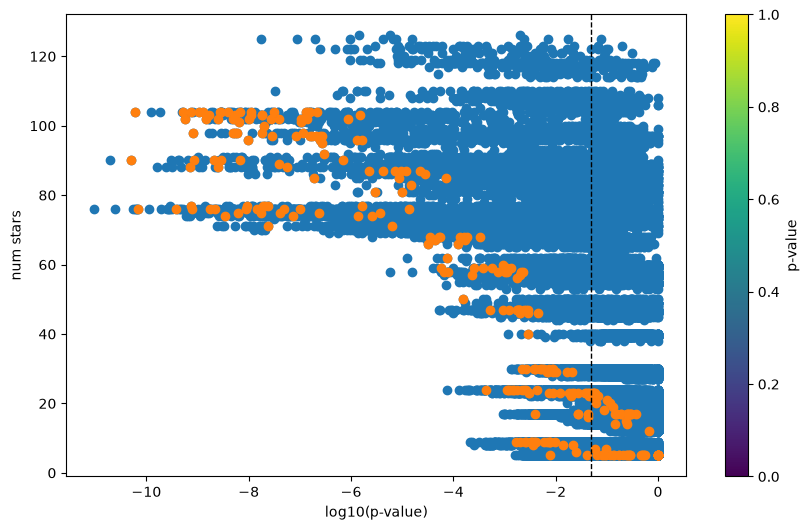

In [42]:
plt.figure(figsize=(10, 6))
# p_value_mask = two_d_test_test_Halo_vs_GSE['p_value'] < 1
mask_ratio = 'k_na'
elm_ratio_mask = (two_d_test_test_Halo_vs_Sequoia['ratio 1'] == mask_ratio) | (two_d_test_test_Halo_vs_Sequoia['ratio 2'] == mask_ratio)

plt.scatter(np.log10(two_d_test_test_Halo_vs_Sequoia['p_value']), two_d_test_test_Halo_vs_Sequoia['num_samples_1'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())
plt.scatter(np.log10(two_d_test_test_Halo_vs_Sequoia[elm_ratio_mask]['p_value']), two_d_test_test_Halo_vs_Sequoia[elm_ratio_mask]['num_samples_1'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())

plt.axvline(np.log10(0.05), color='k', linestyle='--', linewidth=1, label='p = 0.05')

plt.colorbar(label='p-value')
plt.xlabel('log10(p-value)')
plt.ylabel('num stars')

In [101]:
# two_d_test_test_GSE_vs_Sequoia.sort_values(by = 'statistic', ascending = False)[0:40]
two_d_test_test_GSE_vs_Sequoia[0:40]

,ratio 1,ratio 2,p_value,statistic,num_samples_1,num_samples_2
652,cr_ca,nd_y,1.312727e-10,0.081354,561,67
673,mn_ca,nd_y,1.425014e-10,0.080341,561,67
470,mn_mg,nd_y,2.040660e-10,0.078773,561,67
178,mn_na,nd_y,2.159506e-10,0.079750,561,67
808,mn_ti,nd_y,2.602995e-10,0.077932,561,67
793,cr_ti,nd_y,3.170766e-10,0.078794,561,67
442,cr_mg,nd_y,3.235722e-10,0.077510,561,67
142,cr_na,nd_y,6.981782e-10,0.075510,561,67
631,ti_ca,nd_y,8.450272e-10,0.074192,561,67
715,cu_ca,nd_y,9.486921e-10,0.075241,561,67


(array([1.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 3.000e+00, 6.000e+00,
        1.300e+01, 9.000e+00, 1.300e+01, 1.700e+01, 5.000e+00, 3.000e+01,
        2.300e+01, 4.100e+01, 4.000e+01, 5.800e+01, 7.100e+01, 8.200e+01,
        1.110e+02, 1.370e+02, 1.660e+02, 2.030e+02, 2.840e+02, 2.810e+02,
        3.500e+02, 4.100e+02, 4.780e+02, 4.890e+02, 5.720e+02, 6.590e+02,
        7.090e+02, 8.800e+02, 8.730e+02, 9.980e+02, 1.069e+03, 1.265e+03,
        1.478e+03, 1.618e+03, 1.717e+03, 1.973e+03, 2.261e+03, 2.486e+03,
        2.736e+03, 2.722e+03, 2.850e+03, 3.166e+03, 3.371e+03, 3.271e+03,
        2.434e+03, 2.418e+03]),
 array([-12.43475646, -12.18606133, -11.9373662 , -11.68867107,
        -11.43997594, -11.19128081, -10.94258568, -10.69389055,
        -10.44519543, -10.1965003 ,  -9.94780517,  -9.69911004,
         -9.45041491,  -9.20171978,  -8.95302465,  -8.70432952,
         -8.45563439,  -8.20693926,  -7.95824413,  -7.709549  ,
         -7.46085388,  -7.21215875,  -6.96346362,  -6.71

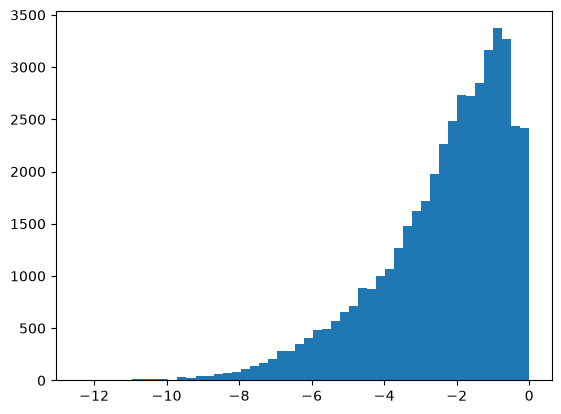

In [61]:
plt.hist(np.log10(two_d_test_test_GSE_vs_Sequoia['p_value']), bins=50)

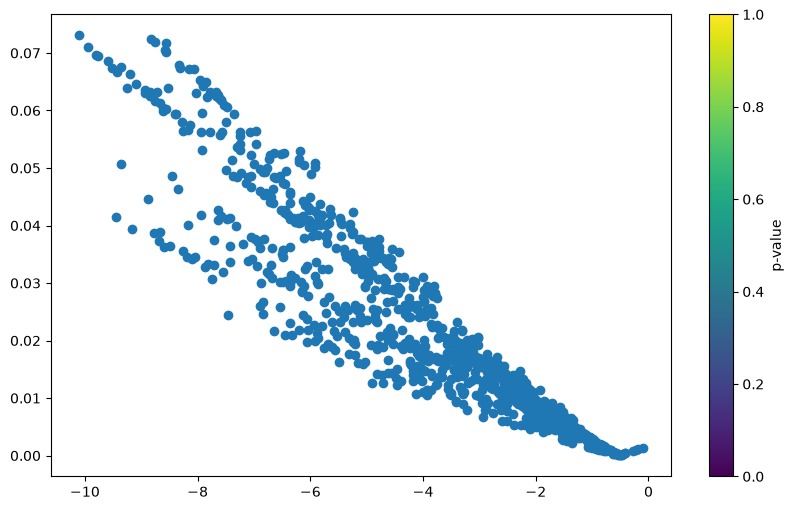

In [62]:
plt.figure(figsize=(10, 6))
p_value_mask = two_d_test_test_GSE_vs_Sequoia['p_value'] < 1
plt.scatter(np.log10(two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value']), two_d_test_test_GSE_vs_Sequoia[p_value_mask]['statistic'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())

plt.colorbar(label='p-value')

In [102]:
# two_d_test_test_Halo_vs_GSE.sort_values(by = 'statistic', ascending = False)[0:40]
two_d_test_test_Halo_vs_GSE[0:40]

,ratio 1,ratio 2,p_value,statistic,num_samples_1,num_samples_2
178,mn_na,nd_y,1.435274e-96,0.163385,561,1254
142,cr_na,nd_y,1.434624e-92,0.158434,561,1254
159,mn_na,cr_ti,2.442454e-88,0.102466,561,1254
123,cr_na,mn_ti,1.522790e-83,0.093355,561,1254
165,mn_na,ni_cr,1.994484e-83,0.098366,561,1254
166,mn_na,cu_cr,2.199476e-83,0.106167,561,1254
214,ni_na,nd_y,3.176616e-83,0.133758,561,1254
70,ca_na,nd_y,9.640287e-83,0.143160,561,1254
130,cr_na,cu_mn,1.159928e-82,0.103578,561,1254
146,mn_na,cr_mg,1.634997e-82,0.093850,561,1254


(array([1.000e+00, 1.000e+00, 1.000e+00, 6.000e+00, 1.200e+01, 7.000e+00,
        9.000e+00, 8.000e+00, 1.200e+01, 1.200e+01, 2.400e+01, 1.900e+01,
        3.000e+01, 3.000e+01, 4.200e+01, 4.500e+01, 4.400e+01, 6.400e+01,
        8.800e+01, 1.020e+02, 9.900e+01, 1.050e+02, 1.700e+02, 1.970e+02,
        2.010e+02, 2.720e+02, 3.510e+02, 4.270e+02, 5.160e+02, 4.820e+02,
        5.730e+02, 7.030e+02, 7.250e+02, 7.950e+02, 9.000e+02, 9.660e+02,
        1.038e+03, 1.175e+03, 1.397e+03, 1.335e+03, 1.421e+03, 1.643e+03,
        1.866e+03, 2.199e+03, 2.420e+03, 3.166e+03, 4.239e+03, 4.800e+03,
        5.612e+03, 4.500e+03]),
 array([-106.82162765, -104.6851951 , -102.54876255, -100.41232999,
         -98.27589744,  -96.13946489,  -94.00303234,  -91.86659978,
         -89.73016723,  -87.59373468,  -85.45730212,  -83.32086957,
         -81.18443702,  -79.04800446,  -76.91157191,  -74.77513936,
         -72.6387068 ,  -70.50227425,  -68.3658417 ,  -66.22940915,
         -64.09297659,  -61.95654404

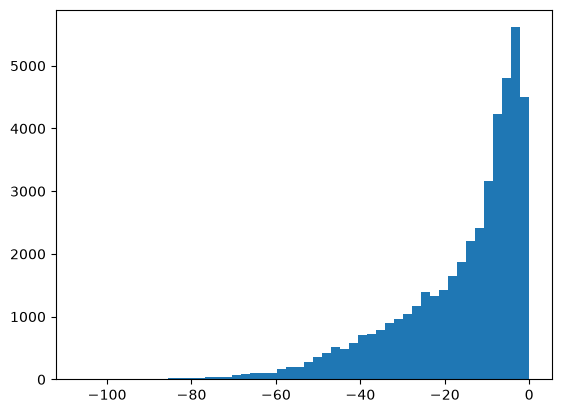

In [22]:
plt.hist(np.log10(two_d_test_test_Halo_vs_GSE['p_value']), bins=50)

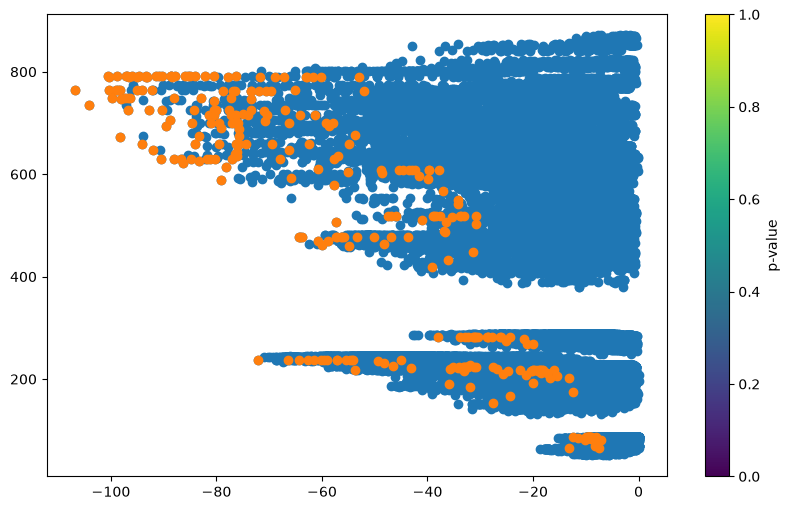

In [23]:
plt.figure(figsize=(10, 6))
# p_value_mask = two_d_test_test_Halo_vs_GSE['p_value'] < 1
mn_na_mask = (two_d_test_test_Halo_vs_GSE['ratio 1'] == 'mn_na') | (two_d_test_test_Halo_vs_GSE['ratio 2'] == 'mn_na')

plt.scatter(np.log10(two_d_test_test_Halo_vs_GSE['p_value']), two_d_test_test_Halo_vs_GSE['num_samples_1'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())
plt.scatter(np.log10(two_d_test_test_Halo_vs_GSE[mn_na_mask]['p_value']), two_d_test_test_Halo_vs_GSE[mn_na_mask]['num_samples_1'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())


plt.colorbar(label='p-value')

In [ ]:
fig,ax = plt.subplots(figsize=(10, 6))

elm_ratio1 = 'sc_fe' #this is pretty good
elm_ratio2 = 'si_v'

elm_ratio1 = 'cr_na' #best for GSE vs Sequoia
elm_ratio2 = 'nd_y'

elm_ratio1 = 'si_v'
elm_ratio2 = 'nd_ca'

elm_ratio1 = 'sc_nd'
elm_ratio2 = 'nd_ca'
elm_ratio3 = 'si_v'
elm_ratio4 = 'si_v'

# elm_ratio1 = 'cr_na'
# elm_ratio2 = 'nd_y'
# elm_ratio3 = 'si_v'
# elm_ratio4 = 'si_mn'


all_x_values = []
all_y_values = []

# plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], color = 'grey', label = 'Halo', s = 2, alpha = 0.5)
# all_x_values.append(galah_Gaia_Halo_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Halo_new_ratios[elm_ratio2])
sns.kdeplot(
    # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    x=galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
    # y=galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Halo'
)

# sns.kdeplot(
#     # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    # x=galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    # y=galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greens',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'GSE'
# )

# all_x_values.append(galah_Gaia_GSE_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_GSE_new_ratios[elm_ratio2])

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'black', label = 'Sequoia', s = 40)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    # y=galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

ax.set_xlabel(F'{elm_ratio1}')
ax.set_ylabel(F'{elm_ratio2}')
leg = ax.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah {elm_ratio2} vs {elm_ratio1}')



In [ ]:
np.mean(galah_Gaia_Sequoia_new_ratios[f'e_{elm_ratio2}'])
# galah_Gaia_Sequoia_new_ratios

In [ ]:
# plt.hist(galah_Gaia_Sequoia_new_ratios[f'e_{elm_ratio1}'], bins = 30)
# for c in galah_Gaia_Sequoia_new_ratios.columns:
#     if 'sn' in c:
#         print(c)
# plt.hist(galah_Gaia_Sequoia_new_ratios[f'snr_px_ccd3'], bins = 30)
plt.hist(galah_Gaia_Sequoia_new_ratios[f'e_na_mn'], bins = 30)

In [33]:
# ratio_list = galah_gaia_new_element_ratio_list
ratio_list = galah_Gaia_new_ratios_nessessary_flags_ratio_list

# ratio_list = ['fe_h']
# ratio_list = one_d_test_test_Halo_vs_Sequoia['ratio'][0:30]
# ratio_list = ['ca_v', 'v_fe', 'ca_fe']


object_list = {
                # 'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags,),  #df
                'Sequoia': (galah_Gaia_Sequoia_new_ratios_nessessary_flags,),
                # 'Halo': (galah_Gaia_Halo_new_ratios,),
                'Pradosh_Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags,),
                # 'Pradosh_Halo': (Halo_Pradosh_galah_Gaia,),
                # 'ran_1': (random_5000_1_new_ratios,),
                # 'ran_2': (random_5000_2_new_ratios,),
}

one_d_test_test_Halo_vs_Sequoia = one_d_ks_test(ratio_list, object_list)

# one_d_test_test_GSE_vs_Sequoia = one_d_ks_test(ratio_list, object_list)

# one_d_test_test_Halo_vs_GSE = one_d_ks_test(ratio_list, object_list)

# one_d_test_test_rndom_5000 = one_d_ks_test(ratio_list, object_list)

# one_d_test_test_GSE_vs_rndom_5000_1 = one_d_ks_test(ratio_list, object_list)

In [23]:
print(len(['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni' 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na']))

27


In [34]:
one_d_test_test_Halo_vs_Sequoia[0:60]
 
# one_d_test_test_Halo_vs_Sequoia_check = one_d_test_test_Halo_vs_Sequoia[one_d_test_test_Halo_vs_Sequoia['ratio'].isin(['mn_ca', 'sc_na', 'sc_cr', 'cr_ca', 'na_ca', 'sc_mn'])]
# one_d_test_test_Halo_vs_Sequoia_check = one_d_test_test_Halo_vs_Sequoia[one_d_test_test_Halo_vs_Sequoia['ratio'].isin(['va_ca', 'nd_y', 'na_mn'])]
# one_d_test_test_Halo_vs_Sequoia_check

# ['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni' 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na']

,ratio,p_value,statistic,num_samples_1,num_samples_2
26,k_na,2.491168e-11,0.350619,105,1622
125,v_ca,1.099999e-10,0.362285,92,1502
28,sc_na,8.459016e-09,0.308015,105,1625
146,cu_sc,1.111481e-08,0.353912,77,1421
130,cu_ca,1.610052e-08,0.350521,77,1421
27,ca_na,1.860326e-08,0.301704,105,1626
188,cu_cr,2.355565e-08,0.351521,75,1387
113,cu_k,9.952895e-08,0.333294,77,1418
200,cu_mn,1.357935e-07,0.332392,76,1398
25,si_na,2.405421e-07,0.288485,99,1541


In [12]:
one_d_test_test_GSE_vs_Sequoia[0:50]

# one_d_test_test_GSE_vs_Sequoia_check = one_d_test_test_GSE_vs_Sequoia[one_d_test_test_GSE_vs_Sequoia['ratio'].isin(['mn_ca', 'sc_na', 'sc_cr', 'cr_ca', 'na_ca', 'sc_mn'])]
# one_d_test_test_GSE_vs_Sequoia_check

NameError: name 'one_d_test_test_GSE_vs_Sequoia' is not defined

In [10]:
one_d_test_test_Halo_vs_GSE[0:50]

# one_d_test_test_Halo_vs_Sequoia_check = one_d_test_test_Halo_vs_Sequoia[one_d_test_test_Halo_vs_Sequoia['ratio'].isin(['mn_ca', 'sc_na', 'sc_cr', 'cr_ca', 'na_ca', 'sc_mn'])]
# one_d_test_test_Halo_vs_GSE_check = one_d_test_test_Halo_vs_GSE[one_d_test_test_Halo_vs_GSE['ratio'].isin(['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni' 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na'])]
# one_d_test_test_Halo_vs_GSE_check

,ratio,p_value,statistic,num_samples_1,num_samples_2
56,mn_na,1.878276e-108,0.474177,791,1603
55,cr_na,3.282312e-91,0.440832,774,1567
66,nd_na,8.595534e-77,0.417045,736,1456
58,ni_na,3.981618e-69,0.378743,801,1623
51,ca_na,7.738942e-69,0.377695,802,1626
276,nd_y,2.013262e-66,0.394538,697,1477
107,nd_al,3.403323e-63,0.607216,244,703
96,cr_al,5.256948e-60,0.590836,245,714
92,ca_al,6.948355e-60,0.590070,245,716
97,mn_al,7.168643e-59,0.591855,238,707


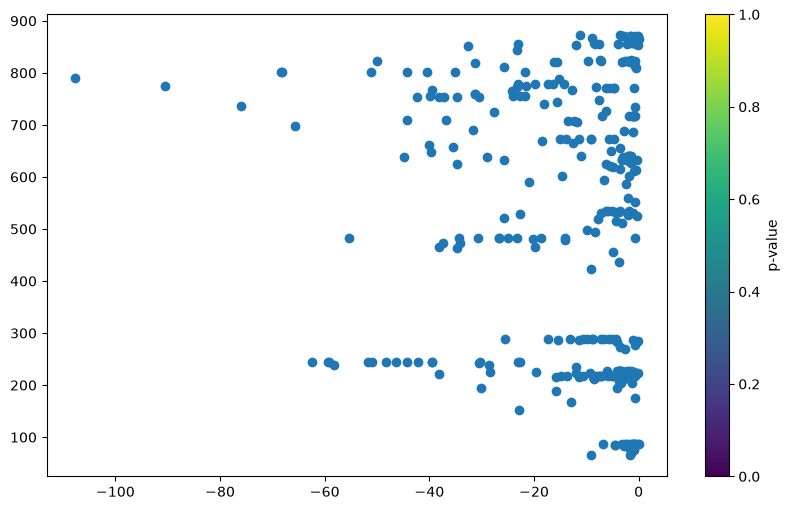

In [13]:
plt.figure(figsize=(10, 6))
# p_value_mask = two_d_test_test_Halo_vs_GSE['p_value'] < 1
plt.scatter(np.log10(one_d_test_test_Halo_vs_GSE['p_value']), one_d_test_test_Halo_vs_GSE['num_samples_1'])#, c=two_d_test_test_GSE_vs_Sequoia[p_value_mask]['p_value'], cmap='rainbow', norm=LogNorm())

plt.colorbar(label='p-value')

In [20]:
ratio_list = galah_gaia_new_element_ratio_list
three_D_ratio_list = n_one_vs_one_n(3, ratio_list, element_list)


# ratio_list = ['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni', 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na']
# ratio_list = ['v_ca', 'nd_y', 'cr_mn', 'na_mn']
# ratio_list = ['ca_v', 'v_fe', 'fe_h', 'na_sc']


object_list = {
                # 'GSE': (galah_Gaia_GSE_new_ratios,),  #df
                'Sequoia': (galah_Gaia_Sequoia_new_ratios,),
                # 'Halo': (galah_Gaia_Halo_new_ratios,),
                'Halo_Pradosh': (Halo_Pradosh_galah_Gaia_new_ratios,),
                # 'ran_1': (random_5000_1_new_ratios,),
                # 'ran_2': (random_5000_2_new_ratios,),
}

three_d_test_test_Halo_vs_Sequoia = three_d_ks_test(three_D_ratio_list, object_list, FE_H = True)

# three_d_test_test_GSE_vs_Sequoia = three_d_ks_test(three_D_ratio_list, object_list)

# three_d_test_test_Halo_vs_GSE = three_d_ks_test(three_D_ratio_list, object_list)

# three_d_test_test_random_5000 = three_d_ks_test(three_D_ratio_list, object_list)

['mg_na', 'sc_ca', 'cr_ti']
['mg_na', 'sc_ca', 'mn_ti']
['mg_na', 'sc_ca', 'ni_ti']
['mg_na', 'sc_ca', 'y_ti']
['mg_na', 'sc_ca', 'ba_ti']
['mg_na', 'sc_ca', 'nd_ti']
['mg_na', 'sc_ca', 'mn_cr']
['mg_na', 'sc_ca', 'ni_cr']
['mg_na', 'sc_ca', 'y_cr']
['mg_na', 'sc_ca', 'ba_cr']
['mg_na', 'sc_ca', 'nd_cr']
['mg_na', 'sc_ca', 'ni_mn']
['mg_na', 'sc_ca', 'y_mn']
['mg_na', 'sc_ca', 'ba_mn']
['mg_na', 'sc_ca', 'nd_mn']
['mg_na', 'sc_ca', 'y_ni']
['mg_na', 'sc_ca', 'ba_ni']
['mg_na', 'sc_ca', 'nd_ni']
['mg_na', 'sc_ca', 'ba_y']
['mg_na', 'sc_ca', 'nd_y']
['mg_na', 'sc_ca', 'nd_ba']
['mg_na', 'ti_ca', 'cr_sc']
['mg_na', 'ti_ca', 'mn_sc']
['mg_na', 'ti_ca', 'ni_sc']
['mg_na', 'ti_ca', 'y_sc']
['mg_na', 'ti_ca', 'ba_sc']
['mg_na', 'ti_ca', 'nd_sc']
['mg_na', 'ti_ca', 'mn_cr']
['mg_na', 'ti_ca', 'ni_cr']
['mg_na', 'ti_ca', 'y_cr']
['mg_na', 'ti_ca', 'ba_cr']
['mg_na', 'ti_ca', 'nd_cr']
['mg_na', 'ti_ca', 'ni_mn']
['mg_na', 'ti_ca', 'y_mn']
['mg_na', 'ti_ca', 'ba_mn']
['mg_na', 'ti_ca', 'nd_mn']
[

In [23]:
three_d_test_test_Halo_vs_Sequoia[0:50] #elm list 16

,ratio 1,ratio 2,ratio 3,p_value,statistic,num_samples_1,num_samples_2
969,sc_na,ni_ca,cr_ti,1.814829e-07,0.036864,79,1365
591,ca_na,ni_sc,cr_ti,3.276570e-07,0.036913,79,1365
547,ca_na,ti_sc,ni_cr,3.339378e-07,0.036428,79,1365
779,sc_na,ti_mg,ni_ca,3.368317e-07,0.034613,79,1365
925,sc_na,ti_ca,ni_cr,3.543748e-07,0.034057,79,1365
970,sc_na,ni_ca,mn_ti,3.758527e-07,0.034372,79,1365
974,sc_na,ni_ca,mn_cr,3.859732e-07,0.034325,79,1365
800,sc_na,cr_mg,ni_ca,5.320711e-07,0.033400,79,1365
401,ca_na,ti_mg,ni_sc,5.387111e-07,0.034901,79,1365
596,ca_na,ni_sc,mn_cr,5.842293e-07,0.034832,79,1365


In [ ]:
three_d_test_test_Halo_vs_Sequoia[0:50] # elm list 7_5

,ratio 1,ratio 2,ratio 3,p_value,statistic,num_samples_1,num_samples_2
45188,ca_v,na_sc,cu_si,1.850508e-10,0.072318,65,1147
47159,ca_v,ca_na,cu_si,3.384600e-10,0.076108,65,1147
46977,ca_v,si_na,cu_ca,3.393952e-10,0.074322,65,1147
45209,ca_v,na_sc,cu_ca,3.661978e-10,0.081590,65,1147
45204,ca_v,na_sc,ti_ca,4.132303e-10,0.067005,65,1147
45207,ca_v,na_sc,co_ca,4.135413e-10,0.071526,65,1147
45187,ca_v,na_sc,ni_si,5.954637e-10,0.064021,65,1147
26875,si_v,ca_v,na_sc,6.077469e-10,0.067175,65,1147
45244,ca_v,na_sc,cu_ni,6.540768e-10,0.065825,65,1147
47215,ca_v,ca_na,cu_ni,6.549802e-10,0.071360,65,1147


In [26]:
three_d_test_test_GSE_vs_Sequoia

,ratio 1,ratio 2,ratio 3,p_value,statistic,num_samples_1,num_samples_2
29050,si_v,cr_sc,nd_y,7.693049e-12,0.091134,527,65
29162,si_v,mn_sc,nd_y,7.825523e-12,0.091590,527,65
173274,cr_sc,mn_si,nd_y,8.460517e-12,0.091033,527,65
32750,si_v,mn_si,nd_y,1.033454e-11,0.090881,527,65
345889,mn_si,cr_k,nd_y,1.197264e-11,0.089203,527,65
...,...,...,...,...,...,...,...
160768,ca_sc,zn_si,ni_co,1.000000e+00,0.001968,527,65
143210,si_sc,k_sc,ba_cr,1.000000e+00,0.001887,527,65
160769,ca_sc,zn_si,cu_co,1.000000e+00,0.001971,527,65
118123,ba_v,k_mg,ni_co,1.000000e+00,0.001978,527,65


In [12]:
three_d_test_test_Halo_vs_GSE

,ratio 1,ratio 2,ratio 3,p_value,statistic,num_samples_1,num_samples_2
207,cr_na,mn_na,nd_y,2.394597e-100,0.182837,587,1258
503,mn_na,cu_mn,nd_y,1.612333e-97,0.159869,587,1258
422,mn_na,cr_ca,nd_y,5.396439e-96,0.149696,587,1258
485,mn_na,cu_cr,nd_y,8.148354e-96,0.157192,587,1258
477,mn_na,mn_cr,nd_y,8.973799e-96,0.150683,587,1258
...,...,...,...,...,...,...,...
676,y_na,cr_ca,y_cu,2.260076e-07,0.008178,587,1258
885,cr_ca,mn_ca,y_cu,3.933151e-07,0.006791,587,1258
731,y_na,mn_cr,y_cu,4.528164e-06,0.006405,587,1258
1005,mn_ca,mn_cr,y_cu,4.608631e-06,0.005473,587,1258


In [22]:
# three_d_test_test_Halo_vs_Sequoia.to_csv('Pradosh_Halo_Galah_phase1_2_Hermes_Halo_vs_Sequoia_3d_ks_test.csv', index=False)
# three_d_test_test_GSE_vs_Sequoia.to_csv('Pradosh_Halo_Galah_phase1_2_Hermes_GSE_vs_Sequoia_3d_ks_test.csv', index=False)

three_d_test_test_Halo_vs_Sequoia.to_csv('Pradosh_Halo_Galah_phase1_2_Hermes_Halo_vs_Sequoia_3d_ks_test_elm_list_16.csv', index=False)


In [27]:
# one_d_test_test_rndom_5000

# one_d_test_test_GSE_vs_rndom_5000_1

galah_Gaia_Pradosh_Halo: 1365 stars, 3 element ratios
galah_Gaia_Sequoia: 79 stars, 3 element ratios


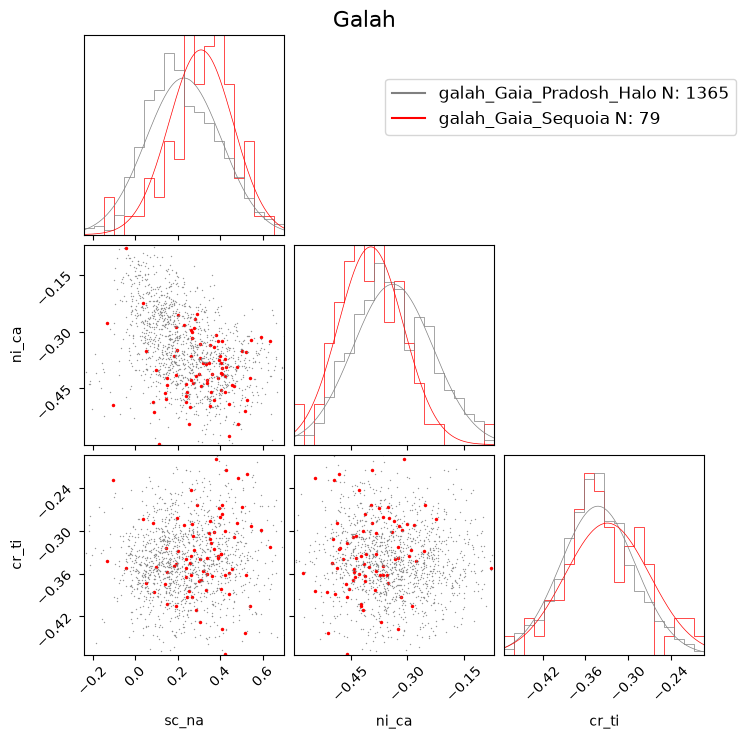

In [32]:
''' MINI CORNER PLOT FOR SPESIFIC GROUP '''

labels = ['v_ca', 'nd_y', 'na_mn'] # best for each object vs eachother (sec/halo, sec/gse, halo/gse)
labels = ['v_ca', 'sc_na',	'si_cu'] # best for sec/halo and two other good ones for sec halo that dont include v or ca, and come up good in sec/gse
labels = ['v_ca', 'si_ni',	'sc_na']
labels = ['sc_na', 'ni_ca',	'cr_ti'] # 3d Halo vs Sequoia
# labels = ['si_v', 'cr_sc',	'nd_y'] # 3d GSE vs Sequoia
# labels = ['cu_cr', 'mn_na', 'nd_y']
e_labels = []
for i in labels:
    e_labels.append('e_' + i)

# for i in range(len(TOP_lables[0])):
    # labels = TOP_lables[0][i]
    # e_labels = TOP_lables[1][i]
    # accuracy_1 = TOP_lables[2][i]
    # accuracy_2 = TOP_lables[3][i]


first_plot = 'galah_Gaia_Sequoia' #pick one of the keys in corner_datasets
n_components = 1
vline_and_hline = False

plot_datapoints= True
plot_contours=False
fill_contours=False
plot_density=False

corner_datasets = {
    # "galah_Gaia_Halo": (galah_Gaia_Halo_new_ratios[labels], galah_Gaia_Halo_new_ratios[e_labels],"grey", 1, 0.8),
    "galah_Gaia_Pradosh_Halo": (Halo_Pradosh_galah_Gaia_new_ratios[labels], Halo_Pradosh_galah_Gaia_new_ratios[e_labels],"grey", 1, 0.8),
    # "galah_Thickdisk": (thickdisk_galah_Gaia[labels], thickdisk_galah_Gaia[e_labels],"purple", 2.5, 1.0),
    # "galah_Gaia_GSE": (galah_Gaia_GSE_new_ratios[labels], galah_Gaia_GSE_new_ratios[e_labels],"green", 2.0, 1.0),
    "galah_Gaia_Sequoia": (galah_Gaia_Sequoia_new_ratios[labels], galah_Gaia_Sequoia_new_ratios[e_labels],"red", 2.5, 1.0),
    # "galah_NGC5139": (galah_Gaia_NGC5139_new_ratios[labels], galah_Gaia_NGC5139_new_ratios[e_labels],"blue", 2.5, 1.0),
    # "galah_NGC3201": (galah_Gaia_NGC3201_new_ratios[labels], galah_Gaia_NGC3201_new_ratios[e_labels],"purple", 2.5, 1.0),
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)

first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]

    # Compute reasonable plotting ranges using percentiles
ranges = []

for dim in range(first_values.shape[1]):

    # combine all datasets for consistent limits
    combined = []

    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        combined.append(values[:, dim])

    combined = np.concatenate(combined)

    # remove NaNs/infs
    combined = combined[np.isfinite(combined)]

    # percentile clipping
    low = np.percentile(combined, 1)
    high = np.percentile(combined, 99)

    # optional padding
    padding = 0.05 * (high - low)

    ranges.append((low - padding, high + padding))

fig = corner.corner(
first_values,
labels=labels,
color=first_color,
range = ranges,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
plot_datapoints=plot_datapoints,
plot_contours=plot_contours,
fill_contours=fill_contours,
plot_density=plot_density,
# plot_datapoints=False,
# plot_contours=True,
# fill_contours=True,
# plot_density=True,

contour_kwargs={"linewidths": 0.4, "alpha": 1},
fill_contour_kwargs={"alpha": 0.1},
)

fig.suptitle(f'Galah', fontsize=16, y=0.98)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

def overlay_gaussian(values, errors, color, n_components):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:, i]

        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]

        if len(x) > 5:  # need enough points
            # Fit 2-component Gaussian Mixture
            gmm = GaussianMixture(n_components=n_components)
            gmm.fit(x.reshape(-1, 1))

            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

            pdf = np.zeros_like(x_grid)

            # Sum the two Gaussians
            for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                sigma = np.sqrt(cov[0][0])
                pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                # (optional) plot individual components
                ax.plot(x_grid,
                        weight * norm.pdf(x_grid, mean[0], sigma),
                        color=color,
                        lw=1,
                        # ls='dashed',
                        ls = "none",
                        alpha=0.7)

            # Plot total mixture
            ax.plot(x_grid, pdf, color=color, lw=0.5)

                #These next couple things will plot the verticle and horizontal lines
            if vline_and_hline == True:
                max_index = np.argmax(pdf)
                peak_x = x_grid[max_index]
                peak_y = pdf[max_index]

                print("Peak x:", peak_x)
                print("Peak pdf:", peak_y)

                # ax.axvline(peak_x, color=color, lw=1)
                for row in range(ndim):

                    if row >= i:

                        ax_col = axes[row, i]

                        ax_col.axvline(
                            peak_x,
                            color=color,
                            lw=1,
                            alpha=0.8
                        )
                
                # draw horizontal line through entire row
                for col in range(ndim):

                    # lower triangle exists
                    if i >= col:

                        ax_row = axes[i, col]

                        ax_row.axhline(
                            peak_x,
                            color=color,
                            lw=1,
                            alpha=0.8
                        )

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            range = ranges,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
            plot_datapoints=plot_datapoints,
            plot_contours=plot_contours,
            fill_contours=fill_contours,
            plot_density=plot_density,
            contour_kwargs={"linewidths": 0.4, "alpha": 0.8},
            # fill_contour_kwargs={"alpha": 0.1},
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color, n_components)
    handles.append(plt.Line2D([0], [0], color = color, label = f'{key} N: {values.shape[0]}'))

fig.legend(handles=handles,
        loc="upper right",
        bbox_to_anchor=(1.0, 0.90),
        #    ncol=len(handles),
        #    frameon=False,
        fontsize=12)

In [ ]:
ratio_list = galah_gaia_new_element_ratio_list
# ratio_list = ['fe_h']
ratio_list = ['nd_y', 'si_mn', 'si_nd']
ratio_list = ['sc_v', 'v_ca', 'sc_na', 'si_v', 'co_sc']
# ratio_list = ['co_sc', 'sc_na', 'cr_k', 'sc_ni', 'cr_sc', 'si_cu', 'sc_cu', 'co_k', 'si_na', 'sc_mn', 'k_ni', 'co_si', 'k_na', 'k_mn', 'si_ni', 'k_cu', 'sc_ti', 'co_zn', 'sc_ba', 'sc_ba', 'na_zn', 'na_ti', 'si_mn', 'cr_cu', 'zn_mn', 'co_ti', 'ti_cu', 'nd_na']
# ratio_list = one_d_test_test_rndom_5000['ratio'][0:15]
# ratio_list = one_d_test_test_GSE_vs_rndom_5000_1 ['ratio'][0:15]

n_components = 2


object_list = {
                # 'GSE': (galah_Gaia_GSE_new_ratios, 'g', 1, 0.5, 0.02),  #df, color, linewidth, alpha, shift_right
                'Sequoia': (galah_Gaia_Sequoia_new_ratios, 'r', 1, 0.5, 0.10),
                'Halo': (galah_Gaia_Halo_new_ratios, 'grey', 1, 0.5, 0.18),
                # 'ran_1': (random_5000_1_new_ratios, 'blue', 1, 0.5, 0.18),
                # 'ran_2': (random_5000_2_new_ratios, 'r', 1, 0.5, 0.1),
}



for ratio in ratio_list:
    plt.figure(figsize=(10, 6))
    all_values = []

    for key, (df, color, lw, alpha, shift_right) in object_list.items():

        values = df[ratio].to_numpy()
        values = values[np.isfinite(values)]
        all_values.append(values)

        df_copy = df
        num_stars = str(len(df_copy))
        plot_gmm(df_copy[ratio] , f'{key}: N = {num_stars}', color, n_components, maximum_peak = True, shift_right = shift_right)
        plt.hist(df[ratio], density = True, bins  = 30, histtype='step', facecolor = 'none', alpha = alpha, edgecolor=color, linewidth = lw)
        # mean = np.round(np.mean(df[ratio]), 3)
        # plt.axvline(x=mean, color=color, linestyle='--')

    all_values = np.concatenate(all_values)
    low = np.percentile(all_values, 0)
    high = np.percentile(all_values, 100)

    plt.xlim(low, high)

    plt.title(F'Galah {ratio} distribution')
    plt.xlabel(f'[{ratio}]')
    plt.ylabel('density')
    plt.legend()